<a href="https://colab.research.google.com/github/olyadiya/Intro_to_ML/blob/main/log_reg_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [2]:
#Сколько всего текстов в датасете?
total_texts = len(data)
print(f"Всего текстов в датасете: {total_texts}")
print()

Всего текстов в датасете: 1986



In [7]:
#Выведите количество текстов в каждой категории
category_names = {0: 'Хоккей (rec.sport.hockey)', 1: 'Космос (sci.space)'}
data['category_name'] = data['category'].map(category_names)

category_stats = data.groupby('category_name').size().reset_index(name='count')
print(category_stats.to_string(index=False))

            category_name  count
       Космос (sci.space)    987
Хоккей (rec.sport.hockey)    999


### **2. Анализ данных**

In [9]:
# Подсказка: используйте value_counts()
category_name = {0: 'Хоккей (rec.sport.hockey)', 1: 'Космос (sci.space)'}
data['category_name'] = data['category'].map(category_name)
category_counts = data['category_name'].value_counts()
print(category_counts)
print()

category_name
Хоккей (rec.sport.hockey)    999
Космос (sci.space)           987
Name: count, dtype: int64



**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [14]:
import re

def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^a-zа-я\s]', ' ', text)
  text = re.sub(r'\s+', ' ', text)
  text = text.strip()
  return text
  pass

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccall mksol dseg ti com fred j mccall subject re vandalizing the sky article i d mksol apr org


### **4. Создание признаков (векторизация)**

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
# 1. Создайте CountVectorizer (остановитесь на английском)
vectorizer = CountVectorizer(stop_words='english')
# 2. Преобразуйте тексты в числа (fit_transform)
vectorizer = CountVectorizer(stop_words='english')
X_vectorized = vectorizer.fit_transform(data['clean_text'])
# 3. Выведите сколько слов получилось
print(f'всего уникальных слов: {X.shape[1]}')

всего уникальных слов: 24480


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

### **5. Разделение данных**

In [27]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = X_vectorized
y = data['category']
print(f"Размер X: {X.shape}")
print(f"Размер y: {len(y)}")
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"выборка обучающая {X_train.shape}, y_train: {len(y_train)}")
print(f"выборка тест {X_test.shape}, y_test: {len(y_test)}")

Размер X: (1986, 24480)
Размер y: 1986
выборка обучающая (1588, 24480), y_train: 1588
выборка тест (398, 24480), y_test: 398


### **6. Обучение модели**

In [30]:
from sklearn.linear_model import LogisticRegression

# 1. Создайте модель логистической регрессии
model = LogisticRegression()
# 2. Обучите её на обучающих данных
model.fit(X_train, y_train)

LogisticRegression()

In [31]:
# 3. Сделайте предсказания для тестовых данных
from sklearn.metrics import mean_squared_error, r2_score

# Прогнозирование на тестовых данных
y_pred = model.predict(X_test)

Mean Squared Error: 0.007537688442211055
R^2: 0.9698423924025056


### **7. Оценка модели**

In [36]:
from sklearn.metrics import accuracy_score
# Оценка модели
# 1. Вычислите accuracy (точность) модели
accuracy = accuracy_score(y_test, y_pred)
# 2. Выведите результат в процентах
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 99.2462311557789%


**Вопрос:** Какая точность у вашей модели? Что это значит?
accuracy показывают сколько классов было правильно спрогнозировано, значит в моей модели accuracy 99.25% означает, что 99.25% всех текстов модель правильно классифиуировала

### **8. Анализ ошибок**

[[201   1]
 [  2 194]]


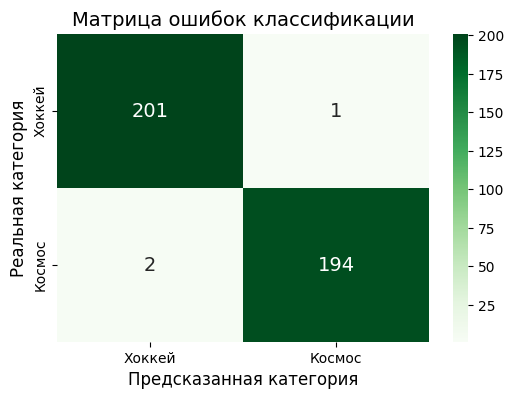

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
# Ваш код здесь
# 1. Создайте матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
# 2. Выведите её
print(cm)
# БОНУС: визуализируйте матрицу ошибок
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', annot_kws={'fontsize': 14}, xticklabels=['Хоккей', 'Космос'], yticklabels=['Хоккей', 'Космос'])
plt.title('Матрица ошибок классификации', fontsize=14)
plt.xlabel('Предсказанная категория', fontsize=12)
plt.ylabel('Реальная категория', fontsize=12)
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

**Ответ:** модель приняла 2 текста про космос как тексты про хоккей